In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Cargar el CSV generado
# Asegúrate de cambiar el nombre del archivo si tu CSV tiene un nombre distinto
df = pd.read_csv('data\dateset.csv')

# Validar la estructura y los primeros datos
print(f"Total de observaciones cargadas: {len(df)}")
df.head()

Total de observaciones cargadas: 638


,gameId,Multiplicador
0,17385155815,2.19
1,17385155915,1.55
2,17385156015,2.27
3,17385156115,6.42
4,17385156215,1.70


In [10]:
# --- CELDA 2 CORREGIDA ---
n_total = len(df)
crashes_100 = (df['Multiplicador'] == 1.00).sum()
epsilon_mle = crashes_100 / n_total

# Intervalo de Confianza exacto (Clopper-Pearson) al 95%
alpha = 0.05
ci_low = stats.beta.ppf(alpha / 2, crashes_100, n_total - crashes_100 + 1) if crashes_100 > 0 else 0.0
ci_high = stats.beta.ppf(1 - alpha / 2, crashes_100 + 1, n_total - crashes_100) if crashes_100 < n_total else 1.0

print("--- ESTIMACIÓN DE PARÁMETROS BÁSICOS ---")
print(f"Muestra total (n): {n_total}")
print(f"Colapsos directos en 1.00x: {crashes_100}")
print(f"Estimador MLE del margen (ε̂): {epsilon_mle:.4f} ({epsilon_mle*100:.2f}%)")
print(f"Intervalo de confianza 95% para ε: [{ci_low:.4f}, {ci_high:.4f}]")

--- ESTIMACIÓN DE PARÁMETROS BÁSICOS ---
Muestra total (n): 638
Colapsos directos en 1.00x: 26
Estimador MLE del margen (ε̂): 0.0408 (4.08%)
Intervalo de confianza 95% para ε: [0.0268, 0.0591]


In [12]:
# --- CELDA 3 DEFINITIVA ---
exitos_150 = (df['Multiplicador'] >= 1.50).sum()
p_obs_150 = exitos_150 / n_total
p_teorica = (1 - 0.03) / 1.50  # 0.646667

# Test Binomial exacto (H1: p > p_teorica)
res_test = stats.binomtest(exitos_150, n_total, p=p_teorica, alternative='greater')

# Intervalo de Confianza exacto (Clopper-Pearson) al 95%
alpha = 0.05
ci_150_low = stats.beta.ppf(alpha / 2, exitos_150, n_total - exitos_150 + 1)
ci_150_high = stats.beta.ppf(1 - alpha / 2, exitos_150 + 1, n_total - exitos_150)

print("--- EVALUACIÓN DE HIPÓTESIS (TARGET >= 1.50x) ---")
print(f"Rondas >= 1.50x observadas: {exitos_150} de {n_total}")
print(f"Tasa observada (p̂): {p_obs_150:.5f} ({p_obs_150*100:.2f}%)")
print(f"Tasa teórica esperada (p_0): {p_teorica:.5f} ({p_teorica*100:.2f}%)")
print(f"Intervalo de Confianza 95% (p): [{ci_150_low:.4f}, {ci_150_high:.4f}]")
print(f"p-valor de la prueba: {res_test.pvalue:.5f}")

if res_test.pvalue < 0.05:
    print("\n=> Rechazamos H0: La tasa es significativamente MAYOR al valor teórico esperable por azar.")
else:
    print("\n=> No se rechaza H0: La diferencia se explica como fluctuación aleatoria muestral.")

--- EVALUACIÓN DE HIPÓTESIS (TARGET >= 1.50x) ---
Rondas >= 1.50x observadas: 415 de 638
Tasa observada (p̂): 0.65047 (65.05%)
Tasa teórica esperada (p_0): 0.64667 (64.67%)
Intervalo de Confianza 95% (p): [0.6121, 0.6875]
p-valor de la prueba: 0.43817

=> No se rechaza H0: La diferencia se explica como fluctuación aleatoria muestral.


In [13]:
# Cálculo del retorno esperado si se automatiza el cobro en 1.50x
retorno_ganancia = 0.50  # Rendimiento neto (+50%)
pérdida_total = -1.00     # Pérdida neta (-100%)

ev_empirico = (p_obs_150 * retorno_ganancia) + ((1 - p_obs_150) * pérdida_total)

print("--- ANÁLISIS DE RENTABILIDAD CON LA MUESTRA ACTUAL ---")
print(f"EV por ronda (con p̂ = {p_obs_150:.4f}): {ev_empirico:+.5f} unidades")

if ev_empirico > 0:
    print("El valor esperado muestral es POSITIVO en esta ventana temporal.")
else:
    print("El valor esperado muestral es NEGATIVO.")

--- ANÁLISIS DE RENTABILIDAD CON LA MUESTRA ACTUAL ---
EV por ronda (con p̂ = 0.6505): -0.02429 unidades
El valor esperado muestral es NEGATIVO.


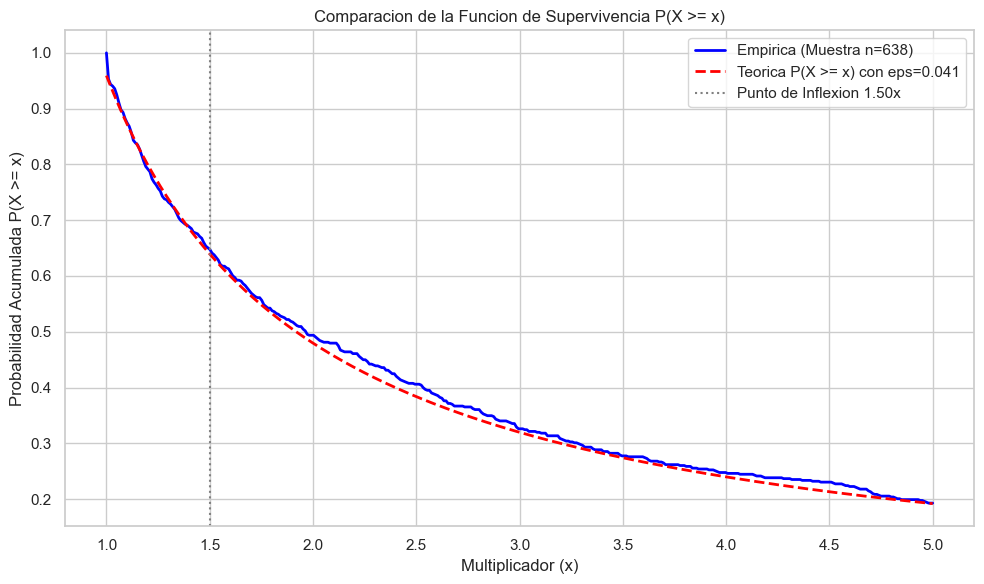

In [15]:
# --- CELDA 5 CORREGIDA ---
x_vals = np.linspace(1.00, 5.00, 400)

# Curva empírica: P(X >= x)
survival_empirica = [(df['Multiplicador'] >= x).mean() for x in x_vals]

# Curva teórica usando el epsilon estimado (o 0.03 por defecto)
epsilon_usado = epsilon_mle if epsilon_mle > 0 else 0.03
survival_teorica = [(1 - epsilon_usado) / x for x in x_vals]

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(x_vals, survival_empirica, label='Empirica (Muestra n=638)', color='blue', lw=2)
plt.plot(x_vals, survival_teorica, label=f'Teorica P(X >= x) con eps={epsilon_usado:.3f}', color='red', linestyle='--', lw=2)

plt.axvline(x=1.50, color='gray', linestyle=':', label='Punto de Inflexion 1.50x')
plt.title('Comparacion de la Funcion de Supervivencia P(X >= x)')
plt.xlabel('Multiplicador (x)')
plt.ylabel('Probabilidad Acumulada P(X >= x)')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# --- CELDA 6 CORREGIDA ---
secuencia = (df['Multiplicador'] >= 1.50).astype(int).values

n1 = float(np.sum(secuencia == 1))
n2 = float(np.sum(secuencia == 0))
n_total_sec = n1 + n2

# Conteo de rachas
rachas = 1.0 + float(np.sum(secuencia[:-1] != secuencia[1:]))

# Esperanza y varianza usando flotantes de 64 bits para evitar overflow
mu_rachas = 1.0 + (2.0 * n1 * n2) / n_total_sec
var_rachas = (2.0 * n1 * n2 * (2.0 * n1 * n2 - n_total_sec)) / ((n_total_sec ** 2) * (n_total_sec - 1.0))

z_score = (rachas - mu_rachas) / np.sqrt(var_rachas)
p_val_runs = 2.0 * (1.0 - stats.norm.cdf(abs(z_score)))

print("--- EVALUACIÓN DE INDEPENDENCIA SECUENCIAL (RUNS TEST) ---")
print(f"Número de rachas observadas: {int(rachas)}")
print(f"Rachas esperadas bajo azar puro: {mu_rachas:.2f}")
print(f"Estadístico Z: {z_score:.4f}")
print(f"p-valor del test de rachas: {p_val_runs:.5f}")

if p_val_runs < 0.05:
    print("\n=> Se rechaza H0: Existen patrones o autocorrelación secuencial.")
else:
    print("\n=> No se rechaza H0: Las rondas son realizaciones i.i.d. (azar puro).")

--- EVALUACIÓN DE INDEPENDENCIA SECUENCIAL (RUNS TEST) ---
Número de rachas observadas: 299
Rachas esperadas bajo azar puro: 291.11
Estadístico Z: 0.6876
p-valor del test de rachas: 0.49169

=> No se rechaza H0: Las rondas son realizaciones i.i.d. (azar puro).


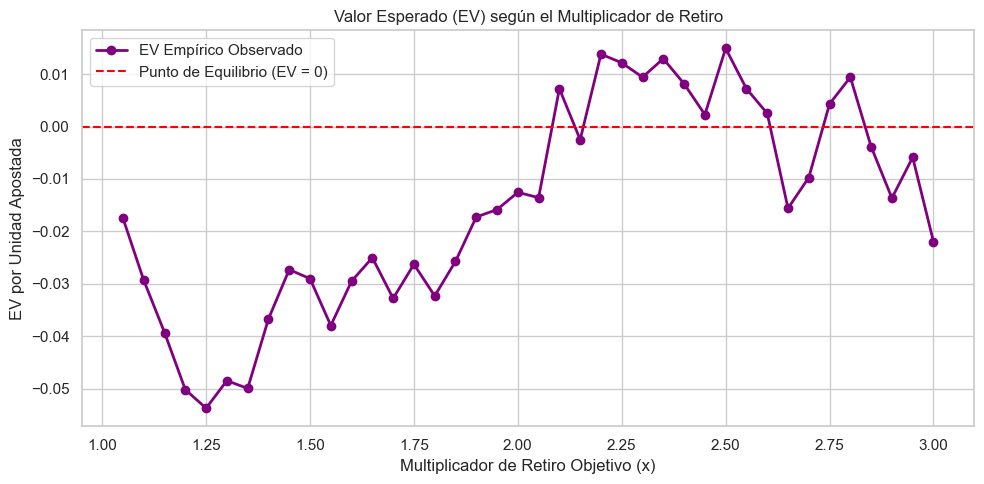

In [18]:
# --- CELDA 7: ANÁLISIS DE SENSIBILIDAD DE EV SEGÚN MULTIPLICADOR ---
targets = np.arange(1.05, 3.05, 0.05)
ev_resultados = []

for t in targets:
    p_emp = (df['Multiplicador'] >= t).mean()
    # Retorno neto si gana es (t - 1), si pierde es -1
    ev = (p_emp * (t - 1.0)) + ((1.0 - p_emp) * -1.0)
    ev_resultados.append(ev)

plt.figure(figsize=(10, 5))
plt.plot(targets, ev_resultados, marker='o', color='purple', linewidth=2, label='EV Empírico Observado')
plt.axhline(y=0, color='red', linestyle='--', label='Punto de Equilibrio (EV = 0)')

plt.title('Valor Esperado (EV) según el Multiplicador de Retiro')
plt.xlabel('Multiplicador de Retiro Objetivo (x)')
plt.ylabel('EV por Unidad Apostada')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# --- CELDA 8: CONTRASTE FORMAL SOBRE EL PICO EN 2.50x ---
target_pico = 2.50
exitos_pico = (df['Multiplicador'] >= target_pico).sum()
p_obs_pico = exitos_pico / n_total

# Probabilidad teórica para >= 2.50x
p_teorica_pico = (1 - 0.03) / target_pico # 0.388 (38.8%)

# Test de una cola (H1: p > p_teorica)
res_pico = stats.binomtest(exitos_pico, n_total, p=p_teorica_pico, alternative='greater')

print("--- EVALUACIÓN DEL PICO EN 2.50x ---")
print(f"Rondas >= 2.50x observadas: {exitos_pico} de {n_total}")
print(f"Tasa observada (p̂): {p_obs_pico:.4f} ({p_obs_pico*100:.2f}%)")
print(f"Tasa teórica esperada: {p_teorica_pico:.4f} ({p_teorica_pico*100:.2f}%)")
print(f"p-valor de la prueba: {res_pico.pvalue:.5f}")

if res_pico.pvalue < 0.05:
    print("=> Inusual: El pico es estadísticamente significativo.")
else:
    print("=> Confirmado: El pico en EV > 0 es ruido muestral por alta varianza (p-valor >= 0.05).")

--- EVALUACIÓN DEL PICO EN 2.50x ---
Rondas >= 2.50x observadas: 259 de 638
Tasa observada (p̂): 0.4060 (40.60%)
Tasa teórica esperada: 0.3880 (38.80%)
p-valor de la prueba: 0.18653
=> Confirmado: El pico en EV > 0 es ruido muestral por alta varianza (p-valor >= 0.05).


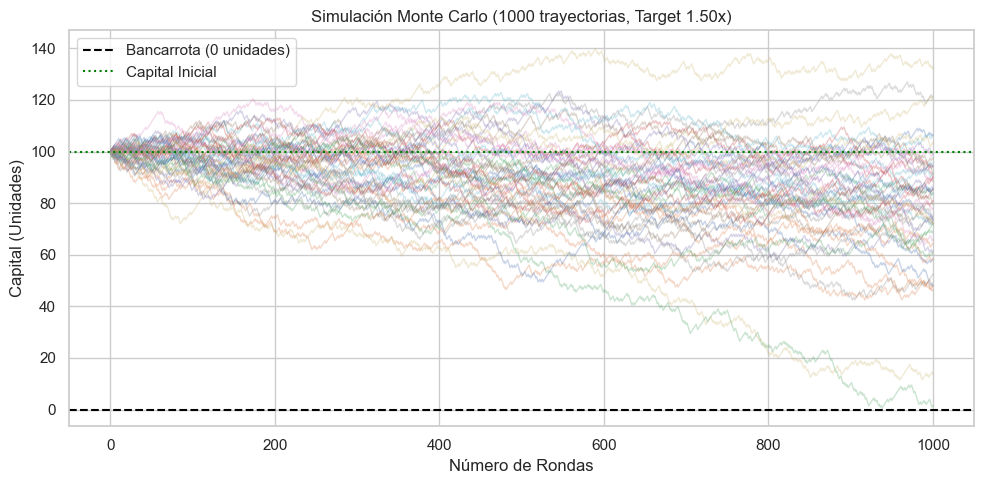

--- RIESGO DE RUINA SIMULADO ---
Probabilidad de bancarrota a 1000 rondas: 0.10%


In [20]:
# --- CELDA 9: SIMULACIÓN DE RISK OF RUIN (MONTE CARLO) ---
np.random.seed(42)

bankroll_inicial = 100  # Unidades de capital
apuesta = 1             # Tamaño de apuesta fijo (1 unidad)
target_x = 1.50         # Retiro en 1.50x
p_exito = p_obs_150     # Usando la tasa observada (65.05%)

n_simulaciones = 1000
max_rondas = 1000

ruinas = 0
trayectorias = []

for _ in range(n_simulaciones):
    saldo = bankroll_inicial
    historia = [saldo]
    
    for _ in range(max_rondas):
        if saldo <= 0:
            ruinas += 1
            break
        
        # Simular resultado
        if np.random.rand() < p_exito:
            saldo += apuesta * (target_x - 1.0) # Ganancia neta
        else:
            saldo -= apuesta                    # Pérdida
            
        historia.append(saldo)
    trayectorias.append(historia)

tasa_ruina = (ruinas / n_simulaciones) * 100

# Graficar un subconjunto de trayectorias
plt.figure(figsize=(10, 5))
for i in range(min(50, n_simulaciones)):
    plt.plot(trayectorias[i], alpha=0.3, lw=1)

plt.axhline(y=0, color='black', linestyle='--', label='Bancarrota (0 unidades)')
plt.axhline(y=bankroll_inicial, color='green', linestyle=':', label='Capital Inicial')
plt.title(f'Simulación Monte Carlo ({n_simulaciones} trayectorias, Target 1.50x)')
plt.xlabel('Número de Rondas')
plt.ylabel('Capital (Unidades)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"--- RIESGO DE RUINA SIMULADO ---")
print(f"Probabilidad de bancarrota a {max_rondas} rondas: {tasa_ruina:.2f}%")

--- MATRIZ DE TRANSICIÓN (ESTADO RECIENTE vs SIGUIENTE) ---
Probabilidades condicionales P(Ronda t | Ronda t-1):
Ronda t         0       1
Ronda t-1                
0.0        0.4923  0.5077
1.0        0.5223  0.4777

Conteo de transiciones:
Ronda t      0    1
Ronda t-1          
0.0        159  164
1.0        164  150

--- PRUEBA CHI-CUADRADO DE INDEPENDENCIA MARKOVIANA ---
Estadístico Chi2: 0.4607
p-valor: 0.49730
=> No se rechaza la independencia: La probabilidad de >= 2.00x es IDÉNTICA sin importar el resultado anterior.


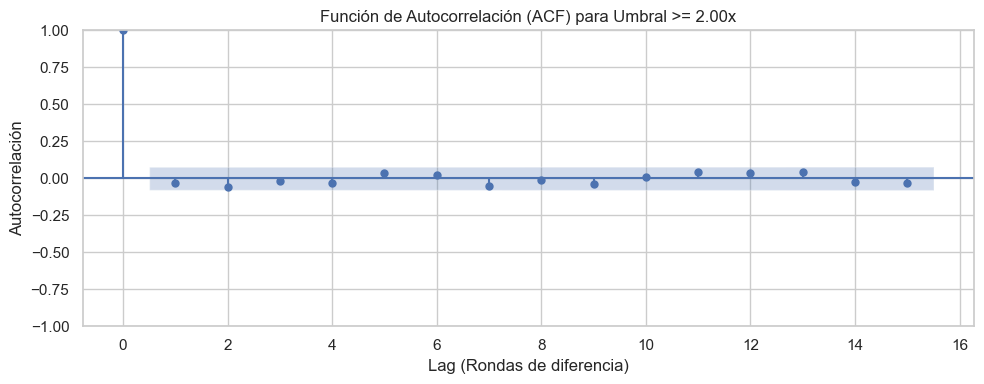

In [21]:
# --- CELDA 10: EVALUACIÓN DE CADENAS DE MARKOV Y AUTOCORRELACIÓN EN EL UMBRAL 2.00x ---
import statsmodels.api as sm

# Crear variable binaria: 1 si es >= 2.00x, 0 si es < 2.00x
estado = (df['Multiplicador'] >= 2.00).astype(int)

# 1. Matriz de Transición de Cadenas de Markov
# Estado t-1 vs Estado t
df_markov = pd.DataFrame({'t_minus_1': estado.shift(1), 't': estado}).dropna()

matriz_conteo = pd.crosstab(df_markov['t_minus_1'], df_markov['t'], rownames=['Ronda t-1'], colnames=['Ronda t'])
matriz_prob = pd.crosstab(df_markov['t_minus_1'], df_markov['t'], normalize='index', rownames=['Ronda t-1'], colnames=['Ronda t'])

# 2. Test Chi-Cuadrado de Independencia
chi2, p_val_chi2, dof, ex = stats.chi2_contingency(matriz_conteo)

print("--- MATRIZ DE TRANSICIÓN (ESTADO RECIENTE vs SIGUIENTE) ---")
print("Probabilidades condicionales P(Ronda t | Ronda t-1):")
print(matriz_prob.round(4))
print("\nConteo de transiciones:")
print(matriz_conteo)

print("\n--- PRUEBA CHI-CUADRADO DE INDEPENDENCIA MARKOVIANA ---")
print(f"Estadístico Chi2: {chi2:.4f}")
print(f"p-valor: {p_val_chi2:.5f}")

if p_val_chi2 < 0.05:
    print("=> ¡ATENCIÓN! Se rechaza la independencia: Hay dependencia del estado anterior (Efecto Racha).")
else:
    print("=> No se rechaza la independencia: La probabilidad de >= 2.00x es IDÉNTICA sin importar el resultado anterior.")

# 3. Graficar Autocorrelación (ACF) de la serie
fig, ax = plt.subplots(figsize=(10, 4))
sm.graphics.tsa.plot_acf(estado, lags=15, ax=ax, title="Función de Autocorrelación (ACF) para Umbral >= 2.00x")
plt.xlabel("Lag (Rondas de diferencia)")
plt.ylabel("Autocorrelación")
plt.tight_layout()
plt.show()

In [22]:
# --- CELDA 11: TEST DE LJUNG-BOX PARA AUTOCORRELACIÓN EN MÚLTIPLES LAGS ---
from statsmodels.stats.diagnostic import acorr_ljungbox

# Evaluar autocorrelación en los primeros 10 Lags (pasos de tiempo)
lb_test = acorr_ljungbox(estado, lags=10, return_df=True)

print("--- PRUEBA DE LJUNG-BOX (DEPENDENCIA TEMPORAL HASTA LAG 10) ---")
print(lb_test.round(4))

p_min = lb_test['lb_pvalue'].min()
print(f"\np-valor mínimo observado en los 10 lags: {p_min:.5f}")

if p_min < 0.05:
    print("=> Existen dependencias temporales en algún rezago (Lag) específico.")
else:
    print("=> Confirmación global: Ningún rezago temporal presenta autocorrelación significativa.")

--- PRUEBA DE LJUNG-BOX (DEPENDENCIA TEMPORAL HASTA LAG 10) ---
    lb_stat  lb_pvalue
1    0.5762     0.4478
2    2.6324     0.2681
3    2.8272     0.4190
4    3.3457     0.5017
5    4.3305     0.5029
6    4.6383     0.5910
7    6.5921     0.4726
8    6.6960     0.5698
9    7.6972     0.5649
10   7.7221     0.6560

p-valor mínimo observado en los 10 lags: 0.26815
=> Confirmación global: Ningún rezago temporal presenta autocorrelación significativa.


In [23]:
# --- CELDA 12: EVALUACIÓN DE CADENAS DE 3 O MÁS RESULTADOS >= 2.00x ---

# Estado binario: 1 si es >= 2.00x, 0 si es < 2.00x
estado = (df['Multiplicador'] >= 2.00).astype(int)

# Crear DataFrame con rezagos t-2, t-1 y t
df_tríos = pd.DataFrame({
    't_minus_2': estado.shift(2),
    't_minus_1': estado.shift(1),
    't': estado
}).dropna()

# Filtrar casos donde HUBO 2 SEGUIDOS (t-2 == 1 y t-1 == 1)
dos_seguidos = df_tríos[(df_tríos['t_minus_2'] == 1) & (df_tríos['t_minus_1'] == 1)]
n_dos_seguidos = len(dos_seguidos)

# De esos casos, cuántos lograron el TERCERO (t == 1)
tres_seguidos = dos_seguidos[dos_seguidos['t'] == 1]
n_tres_seguidos = len(tres_seguidos)

# Probabilidades
p_base_2x = (df['Multiplicador'] >= 2.00).mean()
p_condicional_3er = n_tres_seguidos / n_dos_seguidos if n_dos_seguidos > 0 else 0

# Test binomial: ¿Es la probabilidad del 3er evento significativamente mayor a la probabilidad base?
res_test_3er = stats.binomtest(n_tres_seguidos, n_dos_seguidos, p=p_base_2x, alternative='greater')

print("--- ANÁLISIS DE CADENAS DE SEGUNDO ORDEN (>= 2.00x) ---")
print(f"Total de veces que salieron 2 seguidos (>= 2.00x): {n_dos_seguidos}")
print(f"Veces que el TERCERO también fue >= 2.00x: {n_tres_seguidos}")
print(f"Probabilidad condicional P(3er >= 2 | 2 anteriores >= 2): {p_condicional_3er:.4f} ({p_condicional_3er*100:.2f}%)")
print(f"Probabilidad base sin condicionar P(>= 2.00x): {p_base_2x:.4f} ({p_base_2x*100:.2f}%)")
print(f"p-valor del test binomial: {res_test_3er.pvalue:.5f}")

if res_test_3er.pvalue < 0.05:
    print("\n=> Se rechaza H0: ¡Hay un efecto racha significativo! El 3er disparo se da más de lo esperado.")
else:
    print("\n=> No se rechaza H0: La probabilidad del 3er resultado no cambia tras 2 aciertos previos.")

--- ANÁLISIS DE CADENAS DE SEGUNDO ORDEN (>= 2.00x) ---
Total de veces que salieron 2 seguidos (>= 2.00x): 150
Veces que el TERCERO también fue >= 2.00x: 68
Probabilidad condicional P(3er >= 2 | 2 anteriores >= 2): 0.4533 (45.33%)
Probabilidad base sin condicionar P(>= 2.00x): 0.4937 (49.37%)
p-valor del test binomial: 0.85800

=> No se rechaza H0: La probabilidad del 3er resultado no cambia tras 2 aciertos previos.


--- DISTRIBUCIÓN DE RACHAS CONSECUTIVAS (>= 2.00x) ---
 Longitud Racha (k)  Frecuencia Observada  Frecuencia Teórica
                  1                    83               83.53
                  2                    43               41.24
                  3                    21               20.36
                  4                    12               10.05
                  5                     3                4.96
                  6                     2                2.45
                  8                     1                0.60


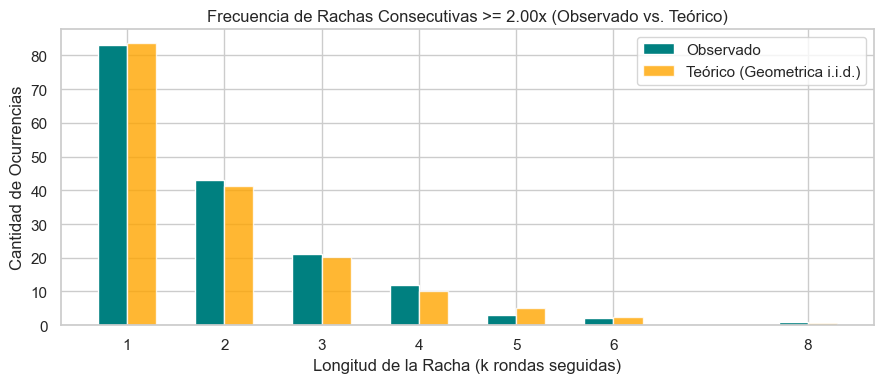

In [24]:
# --- CELDA 13: DISTRIBUCIÓN DE LONGITUD DE RACHAS >= 2.00x ---

# Identificar cambios de estado para agrupar rachas
estado_2x = (df['Multiplicador'] >= 2.00).astype(int)
cambios = (estado_2x != estado_2x.shift(1)).cumsum()

# Filtrar solo los bloques donde la condición fue exitosa (1)
longitudes_rachas = estado_2x.groupby(cambios).apply(lambda x: len(x) if x.iloc[0] == 1 else 0)
longitudes_rachas = longitudes_rachas[longitudes_rachas > 0]

# Conteo de rachas por longitud
conteo_rachas = longitudes_rachas.value_counts().sort_index()

# Frecuencia teórica esperada P(Racha = k) = N_rachas_totales * (p^k * (1-p))
n_bloques_exito = len(longitudes_rachas)
p_base = p_base_2x
k_vals = conteo_rachas.index.values

teorico_rachas = [n_bloques_exito * ((p_base**(k-1)) * (1 - p_base)) for k in k_vals]

df_rachas = pd.DataFrame({
    'Longitud Racha (k)': k_vals,
    'Frecuencia Observada': conteo_rachas.values,
    'Frecuencia Teórica': np.round(teorico_rachas, 2)
})

print("--- DISTRIBUCIÓN DE RACHAS CONSECUTIVAS (>= 2.00x) ---")
print(df_rachas.to_string(index=False))

# Graficar
plt.figure(figsize=(9, 4))
plt.bar(k_vals - 0.15, conteo_rachas.values, width=0.3, label='Observado', color='teal')
plt.bar(k_vals + 0.15, teorico_rachas, width=0.3, label='Teórico (Geometrica i.i.d.)', color='orange', alpha=0.8)
plt.title('Frecuencia de Rachas Consecutivas >= 2.00x (Observado vs. Teórico)')
plt.xlabel('Longitud de la Racha (k rondas seguidas)')
plt.ylabel('Cantidad de Ocurrencias')
plt.xticks(k_vals)
plt.legend()
plt.tight_layout()
plt.show()

--- EVALUACIÓN DE CADENAS DE SEGUNDO ORDEN (>= 1.50x) ---
Ocasiones con 2 seguidos (>= 1.50x): 265
Ocasiones con el TERCERO también >= 1.50x: 170
Probabilidad condicional P(3er >= 1.50 | 2 anteriores >= 1.50): 0.6415 (64.15%)
Probabilidad base sin condicionar P(>= 1.50x): 0.6505 (65.05%)
p-valor del test binomial: 0.64647

--- DISTRIBUCIÓN COMPLETA DE RACHAS (>= 1.50x) ---
 Longitud Racha (k)  Frecuencia Observada  Frecuencia Teórica
                  1                    55               52.43
                  2                    36               34.10
                  3                    16               22.18
                  4                    20               14.43
                  5                     5                9.39
                  6                     8                6.11
                  7                     4                3.97
                  8                     1                2.58
                  9                     1                1.68
    

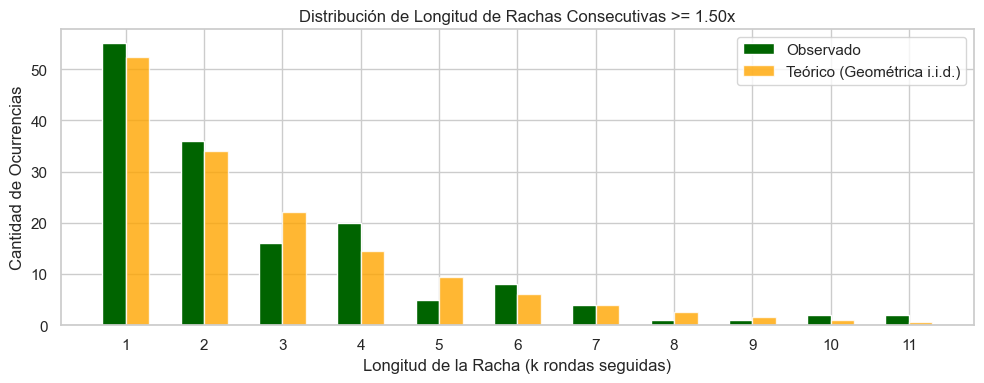

In [30]:
# --- CELDA 14: ANÁLISIS COMPLETO DE RACHAS EN EL UMBRAL >= 1.50x ---

# Estado binario: 1 si es >= 1.50x, 0 si es < 1.50x
estado_150 = (df['Multiplicador'] >= 1.50).astype(int)

# 1. Probabilidad Condicional de Segundo Orden
df_tríos_150 = pd.DataFrame({
    't_minus_2': estado_150.shift(2),
    't_minus_1': estado_150.shift(1),
    't': estado_150
}).dropna()

dos_seguidos_150 = df_tríos_150[(df_tríos_150['t_minus_2'] == 1) & (df_tríos_150['t_minus_1'] == 1)]
n_dos_150 = len(dos_seguidos_150)

tres_seguidos_150 = dos_seguidos_150[dos_seguidos_150['t'] == 1]
n_tres_150 = len(tres_seguidos_150)

p_base_150 = (df['Multiplicador'] >= 1.50).mean()
p_cond_150 = n_tres_150 / n_dos_150 if n_dos_150 > 0 else 0

res_test_150 = stats.binomtest(n_tres_150, n_dos_150, p=p_base_150, alternative='greater')

print("--- EVALUACIÓN DE CADENAS DE SEGUNDO ORDEN (>= 1.50x) ---")
print(f"Ocasiones con 2 seguidos (>= 1.50x): {n_dos_150}")
print(f"Ocasiones con el TERCERO también >= 1.50x: {n_tres_150}")
print(f"Probabilidad condicional P(3er >= 1.50 | 2 anteriores >= 1.50): {p_cond_150:.4f} ({p_cond_150*100:.2f}%)")
print(f"Probabilidad base sin condicionar P(>= 1.50x): {p_base_150:.4f} ({p_base_150*100:.2f}%)")
print(f"p-valor del test binomial: {res_test_150.pvalue:.5f}\n")

# 2. Distribución Sin Restricción de Longitud de Rachas
cambios_150 = (estado_150 != estado_150.shift(1)).cumsum()
longitudes_150 = estado_150.groupby(cambios_150).apply(lambda x: len(x) if x.iloc[0] == 1 else 0)
longitudes_150 = longitudes_150[longitudes_150 > 0]

conteo_150 = longitudes_150.value_counts().sort_index()
n_bloques_150 = len(longitudes_150)
k_vals_150 = conteo_150.index.values

teorico_150 = [n_bloques_150 * ((p_base_150**(k-1)) * (1 - p_base_150)) for k in k_vals_150]

df_rachas_150 = pd.DataFrame({
    'Longitud Racha (k)': k_vals_150,
    'Frecuencia Observada': conteo_150.values,
    'Frecuencia Teórica': np.round(teorico_150, 2)
})

print("--- DISTRIBUCIÓN COMPLETA DE RACHAS (>= 1.50x) ---")
print(df_rachas_150.to_string(index=False))

# Graficar
plt.figure(figsize=(10, 4))
plt.bar(k_vals_150 - 0.15, conteo_150.values, width=0.3, label='Observado', color='darkgreen')
plt.bar(k_vals_150 + 0.15, teorico_150, width=0.3, label='Teórico (Geométrica i.i.d.)', color='orange', alpha=0.8)
plt.title('Distribución de Longitud de Rachas Consecutivas >= 1.50x')
plt.xlabel('Longitud de la Racha (k rondas seguidas)')
plt.ylabel('Cantidad de Ocurrencias')
plt.xticks(k_vals_150)
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# --- CELDA 15: EVALUACIÓN DE MULTIPLICADORES DE ALTA PROBABILIDAD (BAJO RIESGO) ---
multiplicadores_bajos = [1.01, 1.02, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.50, 2, 10]
resultados_bajos = []

for m in multiplicadores_bajos:
    exitos = (df['Multiplicador'] >= m).sum()
    p_emp = exitos / n_total
    
    # Rondas necesarias para recuperar 1 derrota
    ganancia_neta = m - 1.0
    rondas_recuperacion = int(np.ceil(1.0 / ganancia_neta)) if ganancia_neta > 0 else 0
    p_sobrevivir_recuperacion = (p_emp ** rondas_recuperacion) * 100
    
    ev = (p_emp * ganancia_neta) + ((1.0 - p_emp) * -1.0)
    
    resultados_bajos.append({
        'Auto-Cashout': f"{m:.2f}x",
        'Probabilidad Éxito (p̂)': f"{p_emp*100:.2f}%",
        'Rondas para recuperar 1 fallo': rondas_recuperacion,
        'P(Sobrevivir Recuperación)': f"{p_sobrevivir_recuperacion:.2f}%",
        'EV por Apuesta': f"{ev:.4f}"
    })

df_bajos = pd.DataFrame(resultados_bajos)
print("--- ANÁLISIS DE OPTIMIZACIÓN DE COBRO AUTOMÁTICO ---")
print(df_bajos.to_string(index=False))

--- ANÁLISIS DE OPTIMIZACIÓN DE COBRO AUTOMÁTICO ---
Auto-Cashout Probabilidad Éxito (p̂)  Rondas para recuperar 1 fallo P(Sobrevivir Recuperación) EV por Apuesta
       1.01x                  95.92%                            100                      1.56%        -0.0312
       1.02x                  95.30%                             50                      9.00%        -0.0280
       1.05x                  93.57%                             20                     26.49%        -0.0175
       1.10x                  88.24%                             10                     28.63%        -0.0293
       1.15x                  83.86%                              7                     29.16%        -0.0357
       1.20x                  79.62%                              6                     25.48%        -0.0445
       1.25x                  76.33%                              4                     33.95%        -0.0458
       1.30x                  73.67%                              4

In [31]:
# --- CELDA 16: EVALUACIÓN DE COMPENSACIÓN TRAS 4 DERROTAS CONSECUTIVAS (< 2.00x) ---

# Estado binario: 1 si es >= 2.00x, 0 si es < 2.00x
estado = (df['Multiplicador'] >= 2.00).astype(int)

# Crear DataFrame con rezagos t-4, t-3, t-2, t-1 y t
df_cinco = pd.DataFrame({
    't_minus_4': estado.shift(4),
    't_minus_3': estado.shift(3),
    't_minus_2': estado.shift(2),
    't_minus_1': estado.shift(1),
    't': estado
}).dropna()

# Filtrar casos donde hubo 4 DERROTAS SEGUIDAS (< 2.00x)
cuatro_derrotas = df_cinco[
    (df_cinco['t_minus_4'] == 0) & 
    (df_cinco['t_minus_3'] == 0) & 
    (df_cinco['t_minus_2'] == 0) & 
    (df_cinco['t_minus_1'] == 0)
]
n_cuatro_derrotas = len(cuatro_derrotas)

# De esos casos, cuántos lograron la VICTORIA en el quinto intento (t == 1)
quinto_éxito = cuatro_derrotas[cuatro_derrotas['t'] == 1]
n_quinto_éxito = len(quinto_éxito)

# Probabilidades
p_base_2x = (df['Multiplicador'] >= 2.00).mean()
p_cond_quinto = n_quinto_éxito / n_cuatro_derrotas if n_cuatro_derrotas > 0 else 0

# Test binomial de una cola (H1: p_cond > p_base)
res_quinto = stats.binomtest(n_quinto_éxito, n_cuatro_derrotas, p=p_base_2x, alternative='greater')

print("--- ANÁLISIS DE COMPENSACIÓN (4 DERROTAS < 2.00x -> 5ta RONDA) ---")
print(f"Total de veces que salieron 4 seguidas < 2.00x: {n_cuatro_derrotas}")
print(f"Veces que la QUINTA ronda fue >= 2.00x: {n_quinto_éxito}")
print(f"Probabilidad condicional P(5ta >= 2 | 4 anteriores < 2): {p_cond_quinto:.4f} ({p_cond_quinto*100:.2f}%)")
print(f"Probabilidad base sin condicionar P(>= 2.00x): {p_base_2x:.4f} ({p_base_2x*100:.2f}%)")
print(f"p-valor del test binomial: {res_quinto.pvalue:.5f}")

if res_quinto.pvalue < 0.05:
    print("\n=> Anómalo: Se detecta un efecto de compensación significativo en la 5ta ronda.")
else:
    print("\n=> Confirmado: No hay efecto de compensación. La 5ta ronda sigue manteniendo la probabilidad base (~50%).")

--- ANÁLISIS DE COMPENSACIÓN (4 DERROTAS < 2.00x -> 5ta RONDA) ---
Total de veces que salieron 4 seguidas < 2.00x: 34
Veces que la QUINTA ronda fue >= 2.00x: 18
Probabilidad condicional P(5ta >= 2 | 4 anteriores < 2): 0.5294 (52.94%)
Probabilidad base sin condicionar P(>= 2.00x): 0.4937 (49.37%)
p-valor del test binomial: 0.40333

=> Confirmado: No hay efecto de compensación. La 5ta ronda sigue manteniendo la probabilidad base (~50%).


--- DISTRIBUCIÓN DE RACHAS DE DERROTAS (< 2.00x) ---
 Longitud Racha (< 2.00x)  Frecuencia Observada  Frecuencia Teórica
                        1                    78               80.97
                        2                    47               40.99
                        3                    21               20.75
                        4                    10               10.51
                        5                     4                5.32
                        6                     3                2.69
                       10                     1                0.18


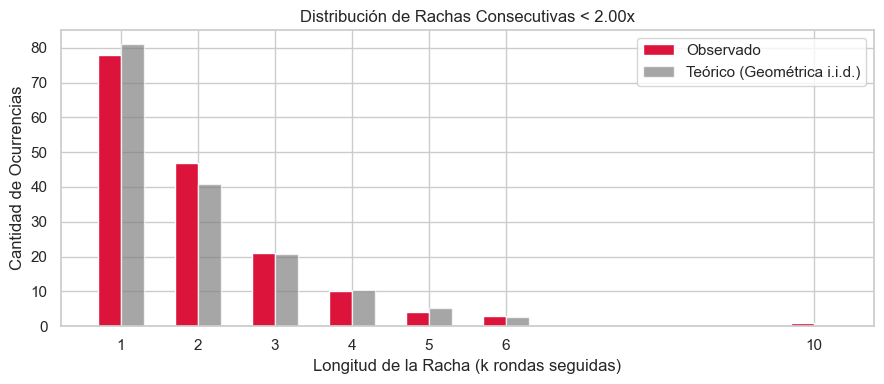

In [32]:
# --- CELDA 17: DISTRIBUCIÓN COMPLETA DE RACHAS BAJAS (< 2.00x) ---

# Identificar bloques de resultados < 2.00x
estado_bajo = (df['Multiplicador'] < 2.00).astype(int)
cambios_bajo = (estado_bajo != estado_bajo.shift(1)).cumsum()

# Extraer longitudes de bloques donde la condición se cumple
longitudes_bajo = estado_bajo.groupby(cambios_bajo).apply(lambda x: len(x) if x.iloc[0] == 1 else 0)
longitudes_bajo = longitudes_bajo[longitudes_bajo > 0]

conteo_bajo = longitudes_bajo.value_counts().sort_index()
n_bloques_bajo = len(longitudes_bajo)
k_vals_bajo = conteo_bajo.index.values

p_fallo = 1.0 - p_base_2x # Probabilidad de sacar < 2.00x (~50.63%)
teorico_bajo = [n_bloques_bajo * ((p_fallo**(k-1)) * (1 - p_fallo)) for k in k_vals_bajo]

df_rachas_bajo = pd.DataFrame({
    'Longitud Racha (< 2.00x)': k_vals_bajo,
    'Frecuencia Observada': conteo_bajo.values,
    'Frecuencia Teórica': np.round(teorico_bajo, 2)
})

print("--- DISTRIBUCIÓN DE RACHAS DE DERROTAS (< 2.00x) ---")
print(df_rachas_bajo.to_string(index=False))

# Graficar
plt.figure(figsize=(9, 4))
plt.bar(k_vals_bajo - 0.15, conteo_bajo.values, width=0.3, label='Observado', color='crimson')
plt.bar(k_vals_bajo + 0.15, teorico_bajo, width=0.3, label='Teórico (Geométrica i.i.d.)', color='gray', alpha=0.7)
plt.title('Distribución de Rachas Consecutivas < 2.00x')
plt.xlabel('Longitud de la Racha (k rondas seguidas)')
plt.ylabel('Cantidad de Ocurrencias')
plt.xticks(k_vals_bajo)
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# --- CELDA 18: SIMULACIÓN DE LA ESTRATEGIA "ESPERAR 4 DERROTAS" ---

# Identificar exactamente las rondas donde el usuario ENTRARÍA a apostar a 2.00x
# Se entra a apostar en t SI Y SOLO SI (t-4, t-3, t-2, t-1) fueron < 2.00x
entradas = (
    (estado.shift(1) == 0) & 
    (estado.shift(2) == 0) & 
    (estado.shift(3) == 0) & 
    (estado.shift(4) == 0)
)

rondas_apostadas = df[entradas]
aciertos = (rondas_apostadas['Multiplicador'] >= 2.00).sum()
total_apuestas = len(rondas_apostadas)

ev_estrategia = (aciertos * 1.0) + ((total_apuestas - aciertos) * -1.0)

print("--- RENDIMIENTO DE LA ESTRATEGIA 'ESPERAR 4 DERROTAS' ---")
print(f"Oportunidades de entrada encontradas en 638 rondas: {total_apuestas}")
print(f"Apuestas Ganadas (>= 2.00x): {aciertos}")
print(f"Apuestas Perdidas (< 2.00x): {total_apuestas - aciertos}")
print(f"Tasa de Acierto Real: {(aciertos/total_apuestas)*100:.2f}%")
print(f"Ganancia/Pérdida Neta acumulada: {ev_estrategia} unidades")

--- RENDIMIENTO DE LA ESTRATEGIA 'ESPERAR 4 DERROTAS' ---
Oportunidades de entrada encontradas en 638 rondas: 34
Apuestas Ganadas (>= 2.00x): 18
Apuestas Perdidas (< 2.00x): 16
Tasa de Acierto Real: 52.94%
Ganancia/Pérdida Neta acumulada: 2.0 unidades
